# Model Training, Testing

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    f1_score, auc, roc_auc_score, confusion_matrix, balanced_accuracy_score,
    roc_curve, accuracy_score, recall_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [3]:
import os
df = pd.read_csv(os.path.join('..', 'data', 'data_clean.csv'), index_col=0)
df

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke
0,Urban,Male,0,1,Yes,Private,formerly smoked,67.0,228.69,36.6,1
2,Rural,Male,0,1,Yes,Private,never smoked,80.0,105.92,32.5,1
3,Urban,Female,0,0,Yes,Private,smokes,49.0,171.23,34.4,1
4,Rural,Female,1,0,Yes,Self-employed,never smoked,79.0,174.12,24.0,1
5,Urban,Male,0,0,Yes,Private,formerly smoked,81.0,186.21,29.0,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Rural,Female,0,0,No,children,Unknown,13.0,103.08,18.6,0
5106,Urban,Female,0,0,Yes,Self-employed,never smoked,81.0,125.20,40.0,0
5107,Rural,Female,0,0,Yes,Self-employed,never smoked,35.0,82.99,30.6,0
5108,Rural,Male,0,0,Yes,Private,formerly smoked,51.0,166.29,25.6,0


### Repeating The Established Preprocessing Steps on Raw Data

In [4]:
df['is_urban'] = (df['Residence_type'] == 'Urban').astype(np.int8)
df['is_male'] = (df['gender'] == 'Male').astype(np.int8)
df['ever_married'] = (df['ever_married'] == 'Yes').astype(np.int8)

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 50, 65, np.inf],
    labels=['<18', '18-35', '36-50', '51-65', '65+']
)

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df['avg_glucose_category'] = pd.cut(
    df['avg_glucose_level'],
    bins=[0, 70, 100, 250, np.inf],
    labels=['Low', 'Normal', 'High', 'VeryHigh']
)

df['ever_smoked'] = (df['smoking_status'].apply(
    lambda x: 1 if x in ['formerly smoked', 'smokes'] else 0
)).astype(np.int8)

df['age_bmi_interaction'] = df['age'] * df['bmi']

df['health_risk_score'] = (
    df['hypertension'] + df['heart_disease'] + df['ever_smoked'] + df['age'] / 100
)

df['work_residence_interaction'] = df['work_type'] + "_" + df['Residence_type']

df['marital_age_interaction'] = df['ever_married'] * df['age']

df

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,...,is_urban,is_male,age_group,bmi_category,avg_glucose_category,ever_smoked,age_bmi_interaction,health_risk_score,work_residence_interaction,marital_age_interaction
0,Urban,Male,0,1,1,Private,formerly smoked,67.0,228.69,36.6,...,1,1,65+,Obese,High,1,2452.2,2.67,Private_Urban,67.0
2,Rural,Male,0,1,1,Private,never smoked,80.0,105.92,32.5,...,0,1,65+,Obese,High,0,2600.0,1.80,Private_Rural,80.0
3,Urban,Female,0,0,1,Private,smokes,49.0,171.23,34.4,...,1,0,36-50,Obese,High,1,1685.6,1.49,Private_Urban,49.0
4,Rural,Female,1,0,1,Self-employed,never smoked,79.0,174.12,24.0,...,0,0,65+,Normal,High,0,1896.0,1.79,Self-employed_Rural,79.0
5,Urban,Male,0,0,1,Private,formerly smoked,81.0,186.21,29.0,...,1,1,65+,Overweight,High,1,2349.0,1.81,Private_Urban,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,Rural,Female,0,0,0,children,Unknown,13.0,103.08,18.6,...,0,0,<18,Normal,High,0,241.8,0.13,children_Rural,0.0
5106,Urban,Female,0,0,1,Self-employed,never smoked,81.0,125.20,40.0,...,1,0,65+,Obese,High,0,3240.0,0.81,Self-employed_Urban,81.0
5107,Rural,Female,0,0,1,Self-employed,never smoked,35.0,82.99,30.6,...,0,0,18-35,Obese,Normal,0,1071.0,0.35,Self-employed_Rural,35.0
5108,Rural,Male,0,0,1,Private,formerly smoked,51.0,166.29,25.6,...,0,1,51-65,Overweight,High,1,1305.6,1.51,Private_Rural,51.0


In [5]:
df.drop(['Residence_type', 'gender'], axis=1, inplace=True)

In [6]:
cat_encode_cols = [
    'hypertension', 'heart_disease', 'work_type', 'smoking_status', 'is_urban',
    'is_male', 'age_group', 'bmi_category', 'avg_glucose_category', 'ever_smoked',
    'ever_married', 'work_residence_interaction',
]

df = pd.get_dummies(df, columns=cat_encode_cols, drop_first=True)

for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(np.int8)

In [7]:
y = df["stroke"]
X = df.drop("stroke", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=7, stratify=y # different `random_state`
)

scaler = MinMaxScaler()

num_features = [
    'age', 'avg_glucose_level', 'bmi', 'age_bmi_interaction',
    'health_risk_score', 'marital_age_interaction'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

OVERSAMPLING_FACTOR = 0.1
over = SMOTE(sampling_strategy=OVERSAMPLING_FACTOR, random_state=42)
X_train_scaled_smote, y_train_smote = over.fit_resample(X_train_scaled, y_train)

In [8]:
removed_features = ['age', 'bmi', 'avg_glucose_level', 'age_bmi_interaction',
                    'marital_age_interaction']
X_train_scaled_smote_modified = X_train_scaled_smote.drop(removed_features, axis=1)
X_test_scaled_modified = X_test_scaled.drop(removed_features, axis=1)

### Models

In [13]:
os.chdir('..')
from utils import plot_confusion_matrix, plot_roc

In [10]:
from sklearn.model_selection import cross_val_score

models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('KNN',                 KNeighborsClassifier()),
    ('Decision Tree',       DecisionTreeClassifier()),
    ('Random Forest',       RandomForestClassifier()),
    ('SVC',                 SVC()),
    ('Gradient Boosting',   GradientBoostingClassifier()),
    ('XGBoost',             XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
]

Since recall is the more important performance metric (to be able to predict the positive cases more effectively), we will prioritize it in the implementation over overall accuracy. This is justified from a clinical and practical perspective as well; since the dataset and the problem at hand is to do predictive modeling to determine those more vulnerable to stroke, to ultimately modify their lifestyle as much as possible the decision to prioritize recall makes sense.

In [11]:
results = []

for name, model in models:
    cv_scores = cross_val_score(
        model, X_train_scaled_smote_modified, y_train_smote, cv=5, scoring="recall"
    )
    mean_acc = round(np.mean(cv_scores), 4)
    results.append({"Model": name, "CV Recall": mean_acc})
    print(f"{name:25s}  CV Recall: {mean_acc}")

results_df = pd.DataFrame(results).sort_values("CV Recall", ascending=False)
results_df

Logistic Regression        CV Recall: 0.1846
KNN                        CV Recall: 0.3308
Decision Tree              CV Recall: 0.4718
Random Forest              CV Recall: 0.4282
SVC                        CV Recall: 0.0692
Gradient Boosting          CV Recall: 0.2282
XGBoost                    CV Recall: 0.4795


,Model,CV Recall
6,XGBoost,0.4795
2,Decision Tree,0.4718
3,Random Forest,0.4282
1,KNN,0.3308
5,Gradient Boosting,0.2282
0,Logistic Regression,0.1846
4,SVC,0.0692


### XGBoost without removing features

In [12]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.25],
    'scale_pos_weight': [1, 3, 5, 10]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
)

xgb_grid.fit(
    X_train_scaled_smote,
    y_train_smote
)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.25],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [200, 400],
                         'scale_pos_weight': [1, 3, 5, 10]},
             scoring='recall')

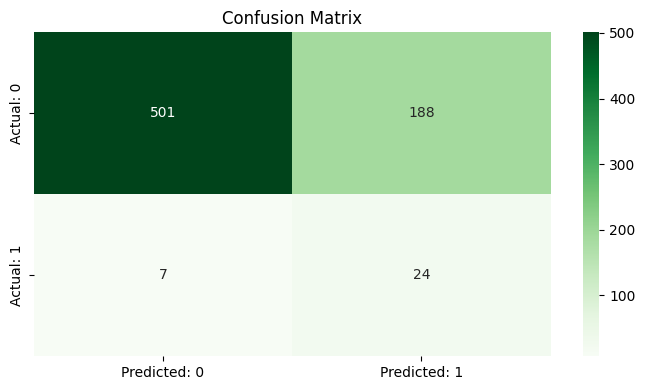

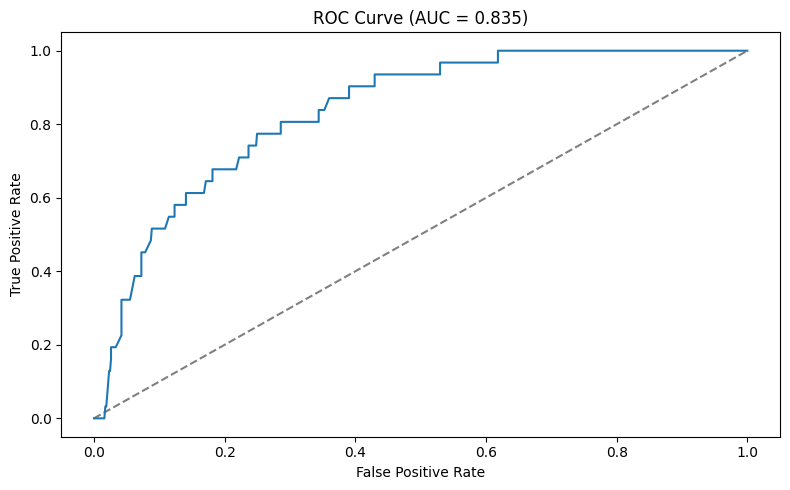

XGBoost All Features Accuracy: 0.7291666666666666
XGBoost All Features F1: 0.19753086419753085
XGBoost All Features Recall: 0.7741935483870968


In [16]:
y_pred = xgb_grid.predict(X_test_scaled)
plot_confusion_matrix(y_test, y_pred)
plot_roc(xgb_grid, X_test_scaled, y_test)
print(f"XGBoost All Features Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"XGBoost All Features F1: {f1_score(y_test, y_pred, labels=[1])}")
print(f"XGBoost All Features Recall: {recall_score(y_test, y_pred, labels=[1])}")

### XGBoost using modified dataframe

In [17]:
xgb_grid_mod = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
)

xgb_grid_mod.fit(
    X_train_scaled_smote_modified,
    y_train_smote
)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.25],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [200, 400],
                         'scale_pos_weight': [1, 3, 5, 10]},
             scoring='recall')

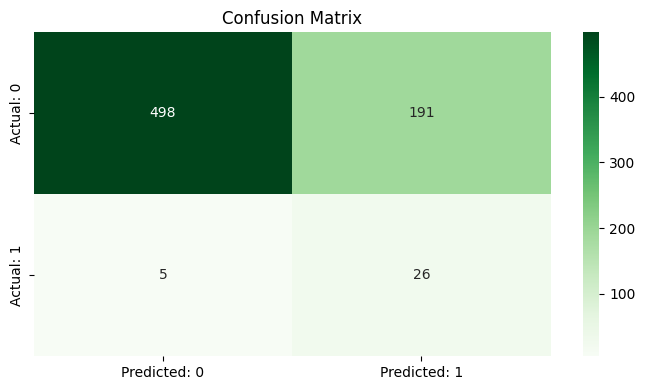

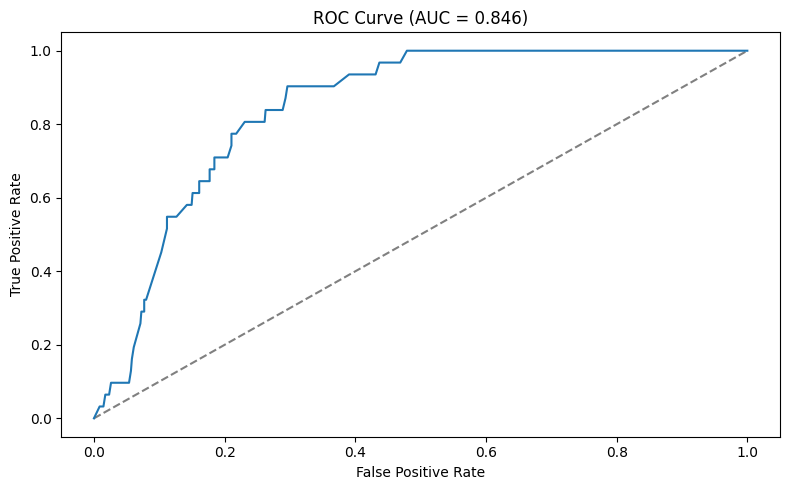

XGBoost All Features Accuracy: 0.7277777777777777
XGBoost All Features F1: 0.20967741935483872
XGBoost All Features Recall: 0.8387096774193549


In [18]:
y_pred = xgb_grid_mod.predict(X_test_scaled_modified)
plot_confusion_matrix(y_test, y_pred)
plot_roc(xgb_grid_mod, X_test_scaled_modified, y_test)
print(f"XGBoost All Features Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"XGBoost All Features F1: {f1_score(y_test, y_pred, labels=[1])}")
print(f"XGBoost All Features Recall: {recall_score(y_test, y_pred, labels=[1])}")

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.72      0.84       689
           1       0.12      0.84      0.21        31

    accuracy                           0.73       720
   macro avg       0.55      0.78      0.52       720
weighted avg       0.95      0.73      0.81       720



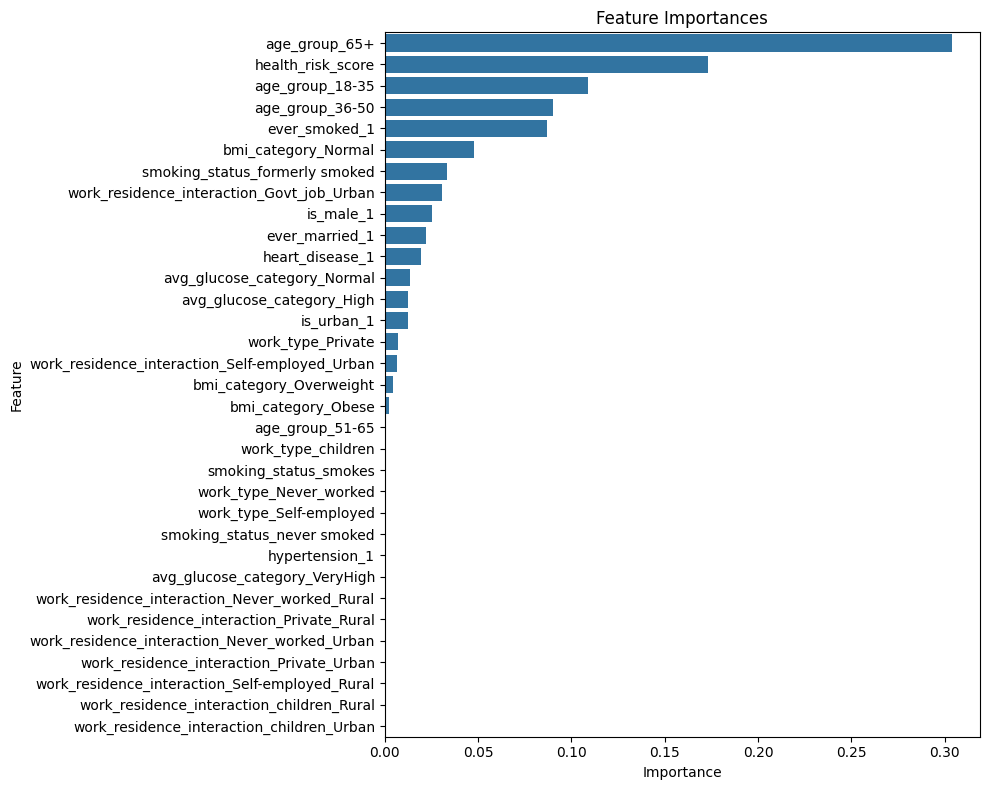

In [22]:
feat_imp = pd.DataFrame({
    "Feature": X_train_scaled_smote_modified.columns,
    "Importance": xgb_grid_mod.best_estimator_.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

### Conclusion

As we can see the best performing model in terms of Recall (Sensitivity), has very low precision (12%) and hence a very low f1 score. The overall accuracy is also much lower than a simple model that predicts "no stroke" would perform (~73% versus ~95%). But the crucial performance metric, which is recall, is much better for the final model (XGBoost), with only the categorical features (numeric features age, bmi, glucose cateogorized and then originals removed), with SMOTE oversampling (factor = 0.1), and using 'recall' as scorer in GridSearch for hyperparameter tuning.

The collection of all those configurations lead to the final 73% XGBoost overall Performance, 84% Recall (Sensitivity), i.e. 84% of those who will experience stroke could be detected with this model early on, and a Precision (Positive Predictive Value) of 12%  means a low portion of those positive predictions, approximately 12%, will actualy experience stroke, and the rest of those dubbed positive will not experience stroke (high False Positive Rate)...

For this particular predictive modeling problem this type of performance is acceptible and preferred to those models that could achieve 95% accuracy, and high precision, with low recall rate, because we can't afford to miss positive cases. Moreover, as we can see among the features, Age group above 65, overall health score (a composite engineered feature encompassing age, glucose, bmi, past medical history), ever_smoked, and other age groups were the most important features, and surprisingly normal bmi and smoking status: formerly smoked contributed a lot to model performance as well (this is not congruent with clinical expectations...).

Also, SMOTE helps but its synthetic samples don't fully replace real stroke cases. Collecting more data especially from underrepresented age and risk groups would help considerably. Log-transforming skewed features like avg_glucose_level might also squeeze out a bit more performance. Finally optimizing the classification threshold via the ROC curve rather than using the default 0.5 cutoff is a straightforward improvement that could further boost recall without sacrificing too much precision.